# SAR-to-Height Data Preparation for Cordiff Training

This notebook provides a complete end-to-end pipeline for preparing SAR intensity and DSM height data for the cordiff training system. The pipeline converts raw TIFF files into cordiff-compatible NetCDF patches following the same structure as the weather data pipeline.

## Pipeline Overview

The SAR-to-height data preparation follows these key steps:

1. **Data Discovery & Loading**: Identify matching SAR intensity and DSM TIFF file pairs
2. **Data Validation**: Check file integrity and compatibility
3. **Spatial Coregistration**: Align SAR and DSM data to common spatial grid
4. **Feature Extraction**: Generate 13 enriched features from SAR intensity data
5. **Patch Generation**: Create 432×432 patches with quality assessment
6. **AOI Management**: Prevent spatial overlaps between different datasets
7. **NetCDF Export**: Save patches in cordiff-compatible format
8. **Visualization & Analysis**: Comprehensive data exploration and quality assessment

## Key Features

- **Multi-channel SAR features**: 13 derived features including speckle filtering, texture analysis, and edge detection
- **Quality control**: Automated patch quality assessment and filtering
- **Spatial overlap prevention**: AOI management to avoid training data conflicts
- **Cordiff compatibility**: NetCDF structure matches weather data format from 2-training.ipynb
- **Self-contained processing**: Complete pipeline execution within this notebook

## Setup and Dependencies

### Install required packages if needed

In [1]:
import subprocess
import sys

def install_package(package):
    """Install a package using pip if not already installed."""
    try:
        __import__(package.split('==')[0])
        print(f"✓ {package} already installed")
    except ImportError:
        print(f"📦 Installing {package}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])
        print(f"✓ {package} installed successfully")

# Install required packages
required_packages = [
    'seaborn==0.13.2',
    'rasterio==1.4.4',
    'scikit-image==0.26.0',
    'shapely==2.1.2',
    'pyproj==3.7.2', 
    'cartopy==0.25.0',
    'geopandas==1.1.2',
    'h5netcdf==1.6.3'
]

print("🔧 Installing required packages...")
for package in required_packages:
    try:
        install_package(package)
    except Exception as e:
        print(f"⚠️  Warning: Could not install {package}: {e}")

print("\n✅ Package installation complete!")

🔧 Installing required packages...
✓ seaborn==0.13.2 already installed
✓ rasterio==1.4.4 already installed
📦 Installing scikit-image==0.26.0...
✓ scikit-image==0.26.0 installed successfully
✓ shapely==2.1.2 already installed
✓ pyproj==3.7.2 already installed
✓ cartopy==0.25.0 already installed
✓ geopandas==1.1.2 already installed
✓ h5netcdf==1.6.3 already installed

✅ Package installation complete!



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


### Standard library imports

In [2]:
import os
import sys
from pathlib import Path
import logging
import warnings
from typing import Dict, List, Optional, Tuple
import glob
import json
import time
from datetime import timedelta, datetime

# Scientific computing imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import netCDF4 as nc

# Geospatial and image processing imports
try:
    import rasterio
    from rasterio.transform import from_bounds
    from rasterio.warp import reproject, Resampling
    RASTERIO_AVAILABLE = True
except ImportError:
    RASTERIO_AVAILABLE = False
    print("⚠️  Rasterio not available - some geospatial functions may be limited")

try:
    from shapely.geometry import box, Polygon
    from shapely.ops import unary_union
    SHAPELY_AVAILABLE = True
except ImportError:
    SHAPELY_AVAILABLE = False
    print("⚠️  Shapely not available - AOI management may be limited")

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("✓ Standard imports loaded successfully")

✓ Standard imports loaded successfully


### Local imports

In [39]:
# Add the scripts directory to Python path for local imports
scripts_dir = Path('./5-sar2height').resolve()
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

# Import our custom SAR-to-height processing modules
import_success = {}
import_errors = {}

# Updated module imports including the new modular pipeline and refactored feature extraction
module_imports = [
    ('data_loader', ['SARDataLoader', 'get_data_statistics', 'DatasetStats']),
    ('coregistration', ['CoregistrationProcessor', 'coregister_file_pair']),
    ('feature_extraction', ['SARFeatureExtractor', 'GLCM_AVAILABLE']), 
    ('patch_generation', ['PatchGenerator', 'generate_all_patches_from_data']),  
    ('aoi_management', ['AOIManager', 'check_patch_overlaps']),
    ('netcdf_writer', ['NetCDFPatchWriter', 'save_all_patches_to_directory']),  
    ('patch_filter', ['NetCDFPatchFilter', 'QualityThresholds', 'filter_patch_files']),  
    ('visualization', ['SARDataVisualizer']),
    ('sar2height_pipeline', ['SAR2HeightPipeline', 'PipelineConfig', 'create_pipeline_config', 'create_pipeline']), 
    ('compute_sar2height_stats', ['compute_sar2height_dataset_stats'])
]

for module_name, imports in module_imports:
    try:
        module = __import__(module_name)
        for import_name in imports:
            try:
                globals()[import_name] = getattr(module, import_name)
            except AttributeError:
                if import_name == 'GLCM_AVAILABLE':
                    # Set default value if GLCM_AVAILABLE is not found
                    globals()[import_name] = False
                    print(f"ℹ️  {import_name} not found in {module_name}, defaulting to False")
                elif import_name in ['extract_sar_features', 'extract_selected_sar_features']:
                    # These functions have been deprecated in favor of the SARFeatureExtractor class
                    print(f"⚠️  {import_name} deprecated - use SARFeatureExtractor class instead")
                    continue
                else:
                    print(f"⚠️  Warning: {import_name} not found in {module_name}")
                    continue
        import_success[module_name] = True
    except ImportError as e:
        import_errors[module_name] = str(e)
        import_success[module_name] = False
        print(f"❌ Failed to import {module_name}: {e}")

# Report import status
successful_imports = sum(import_success.values())
total_modules = len(import_success)
pipeline_available = import_success.get('sar2height_pipeline', False)
feature_extraction_available = import_success.get('feature_extraction', False)

print(f"\n📦 Module Import Status: {successful_imports}/{total_modules} modules loaded")

if pipeline_available:
    print("✅ Modular pipeline available!")
else:
    print("⚠️  Pipeline module failed to import")

if feature_extraction_available:
    print("✅ Refactored SARFeatureExtractor class available!")
else:
    print("⚠️  Feature extraction module failed to import")

if successful_imports < total_modules:
    failed_modules = [name for name, success in import_success.items() if not success]
    print(f"❌ Failed modules: {', '.join(failed_modules)}")
    
    # Show detailed error messages for failed imports
    if import_errors:
        print("\n🔍 Import Error Details:")
        for module, error in import_errors.items():
            print(f"  • {module}: {error}")

print(f"\n🚀 Ready for {'modular pipeline' if pipeline_available else 'manual'} processing!")

# Additional status check for key components
if feature_extraction_available and pipeline_available:
    print("🎯 All core components loaded - pipeline ready to use!")
    print("💡 Use create_pipeline_config() and create_pipeline() to get started")
elif feature_extraction_available:
    print("🔧 Feature extraction available - you can use SARFeatureExtractor directly")
elif pipeline_available:
    print("🔧 Pipeline available but feature extraction may have issues")
else:
    print("⚠️  Consider checking module dependencies and file locations")

⚠️  Warning: NetCDFPatchFilter not found in patch_filter

📦 Module Import Status: 10/10 modules loaded
✅ Modular pipeline available!
✅ Refactored SARFeatureExtractor class available!

🚀 Ready for modular pipeline processing!
🎯 All core components loaded - pipeline ready to use!
💡 Use create_pipeline_config() and create_pipeline() to get started


In [4]:
ls /app/data/sar2height

logs/  processed/  processed_/  run2/  visualizations/  visualizations_/


## Configuration and Paths

In [37]:
# =============================================================================
# CONFIGURATION PARAMETERS - Organized for Modular Pipeline
# =============================================================================

from pathlib import Path
import logging

# =============================================================================
# PATHS CONFIGURATION
# =============================================================================

# Base directories
INPUT_DIR = Path("/app/data/sar2height/")
OUTPUT_DIR = Path("/app/outputs/")

# Data paths
RAW_DATA_DIR = INPUT_DIR / "run2"
FULL_PATCHES_DIR = INPUT_DIR / "processed" / "full_patches"
FILTERED_PATCHES_DIR = INPUT_DIR / "processed" / "filtered_patches"
STAT_DIR = INPUT_DIR / "processed" / "filtered_patches" 
VISUALIZATION_DIR = INPUT_DIR / "visualizations"
LOG_DIR = OUTPUT_DIR / "sar2height" / "logs"

# =============================================================================
# PROCESSING PARAMETERS
# =============================================================================

# Core processing settings
PATCH_SIZE = 432  # Compatible with cordiff (must be divisible by powers of 2)
PROCESS_ALL_FILES = True  # Set to False for testing with limited files
MAX_FILES_TO_PROCESS = 14  # Only used if PROCESS_ALL_FILES=False

# Skip processing control
OVERRIDE_EXISTING = False  # Set to True to reprocess existing files, False to skip them
                          # When False: skips files if output already exists (faster)
                          # When True: reprocesses all files regardless of existing output

# =============================================================================
# FEATURE EXTRACTION CONFIGURATION
# =============================================================================

# Feature selection - customize as needed
ENABLED_FEATURES = [
    'intensity_db',                    # Original SAR intensity (dB)
    'intensity_percentile_rescaled',   # 2-98 percentile rescaled
    # 'intensity_linear',                # Linear scale intensity
    # 'intensity_sqrt_linear',           # Square root of linear
    # 'intensity_power_transform',       # Power transform (α=0.3)
    # 'intensity_lee_filtered',          # Lee speckle filter
    # 'local_mean_5x5',                 # Local mean (5x5 window)
    # 'local_std_5x5',                  # Local std (5x5 window)
    # Additional features (uncomment to enable):
    # 'sobel_magnitude',                 # Edge magnitude
    # 'sobel_direction',                 # Edge direction
    # 'texture_contrast',                # GLCM contrast (or alternative)
    # 'texture_homogeneity',             # GLCM homogeneity (or alternative)
    # 'local_mean_3x3',                 # Multi-scale mean (3x3)
    # 'local_mean_7x7',                 # Multi-scale mean (7x7)
    # 'gradient_magnitude',              # Gradient magnitude
    # 'incidence_angle',                 # incidence angle
    # 'local_range'                      # Local range (or incidence angle)
]

# =============================================================================
# QUALITY FILTERING CRITERIA
# =============================================================================

# Data completeness thresholds
MIN_DSM_VALID_PERCENTAGE = 70.0      # Minimum % of valid DSM pixels
MIN_FEATURE_VALID_PERCENTAGE = 70.0  # Minimum % of valid feature pixels
MIN_DATA_COMPLETENESS = 70.0         # Overall data completeness threshold

# DSM variation criteria
MIN_DSM_STD = 0.1                    # Minimum DSM standard deviation (reject flat areas)
MAX_DSM_STD = 1000.0                 # Maximum DSM standard deviation (reject noisy areas)
MIN_DSM_RANGE = 0.5                  # Minimum DSM range (max - min)

# Overall quality threshold
MIN_PATCH_QUALITY = 0.7              # Minimum quality score (0-1)

# =============================================================================
# SPATIAL FILTERING CONFIGURATION
# =============================================================================

# Area of Interest (AOI) overlap settings
AOI_OVERLAP_THRESHOLD = 0.0          # Maximum allowed overlap between AOIs (0-1)
                                     # 0.0 = no overlap allowed
                                     # 0.1 = 10% overlap allowed

# =============================================================================
# VISUALIZATION SETTINGS
# =============================================================================

# Visualization control
SAVE_INDIVIDUAL_VISUALIZATIONS = True   # Save plots for each processed file
VISUALIZATION_SPEED_MODE = False        # Enable speed optimizations
MAX_FEATURES_TO_DISPLAY = 20           # Maximum features to show in plots
FIGURE_DPI = 100                       # Resolution for saved figures
FEATURE_VIZ_DOWNSAMPLE = 1            # Downsample factor for feature display

# =============================================================================
# DIRECTORY CREATION
# =============================================================================

# Create necessary output directories
for directory in [RAW_DATA_DIR, 
                  FULL_PATCHES_DIR,
                  FILTERED_PATCHES_DIR, 
                  VISUALIZATION_DIR,
                  LOG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# =============================================================================
# LOGGING CONFIGURATION
# =============================================================================

logger = logging.getLogger(__name__)

# =============================================================================
# CONFIGURATION SUMMARY
# =============================================================================

print(f"🔧 Configuration Summary:")
print(f"  📁 Data directory: {RAW_DATA_DIR}")
print(f"  📁 Full patches output: {FULL_PATCHES_DIR}")
print(f"  📁 Filtered patches output: {FILTERED_PATCHES_DIR}")
print(f"  📊 Patch size: {PATCH_SIZE}×{PATCH_SIZE}")
print(f"  🎯 Process all files: {PROCESS_ALL_FILES}")
print(f"  ⏭️  Override existing: {OVERRIDE_EXISTING}")
print(f"  🔢 Features enabled: {len(ENABLED_FEATURES)}")
print(f"  📈 Quality thresholds: DSM≥{MIN_DSM_VALID_PERCENTAGE}%, Features≥{MIN_FEATURE_VALID_PERCENTAGE}%")
print(f"  🗺️  Spatial overlap: {AOI_OVERLAP_THRESHOLD}")
print(f"  📊 Visualizations: {'ON' if SAVE_INDIVIDUAL_VISUALIZATIONS else 'OFF'}")

if not PROCESS_ALL_FILES:
    print(f"  ⚠️  Limited processing: {MAX_FILES_TO_PROCESS} files max")

if not OVERRIDE_EXISTING:
    print(f"  💡 Skip mode: Will skip files with existing output (set OVERRIDE_EXISTING=True to reprocess)")
else:
    print(f"  🔄 Override mode: Will reprocess all files regardless of existing output")

🔧 Configuration Summary:
  📁 Data directory: /app/data/sar2height/run2
  📁 Full patches output: /app/data/sar2height/processed/full_patches
  📁 Filtered patches output: /app/data/sar2height/processed/filtered_patches
  📊 Patch size: 432×432
  🎯 Process all files: True
  ⏭️  Override existing: False
  🔢 Features enabled: 2
  📈 Quality thresholds: DSM≥70.0%, Features≥70.0%
  🗺️  Spatial overlap: 0.0
  📊 Visualizations: ON
  💡 Skip mode: Will skip files with existing output (set OVERRIDE_EXISTING=True to reprocess)


## Pipeline

In [6]:
# =============================================================================
# SAR-TO-HEIGHT MODULAR PIPELINE EXECUTION
# =============================================================================

# Create pipeline configuration using our parameters
config = create_pipeline_config(
    raw_data_dir=str(RAW_DATA_DIR),
    output_base_dir=str(INPUT_DIR),
    patch_size=PATCH_SIZE,
    enabled_features=ENABLED_FEATURES,
    process_all_files=PROCESS_ALL_FILES,
    save_visualizations=SAVE_INDIVIDUAL_VISUALIZATIONS,
    override_existing=OVERRIDE_EXISTING,  # New parameter for skip functionality
    # Quality filtering parameters
    min_dsm_valid_percentage=MIN_DSM_VALID_PERCENTAGE,
    min_feature_valid_percentage=MIN_FEATURE_VALID_PERCENTAGE,
    min_data_completeness=MIN_DATA_COMPLETENESS,
    min_dsm_std=MIN_DSM_STD,
    max_dsm_std=MAX_DSM_STD,
    min_dsm_range=MIN_DSM_RANGE,
    aoi_overlap_threshold=AOI_OVERLAP_THRESHOLD,
    # Visualization parameters
    visualization_speed_mode=VISUALIZATION_SPEED_MODE,
    max_features_to_display=MAX_FEATURES_TO_DISPLAY,
    figure_dpi=FIGURE_DPI,
    # Processing limits
    max_files_to_process=MAX_FILES_TO_PROCESS
)

# Create pipeline instance
pipeline = create_pipeline(config)

print("🚀 SAR-to-Height Modular Pipeline Initialized")
print("="*60)
print(f"📁 Input directory: {RAW_DATA_DIR}")
print(f"📁 Output directory: {INPUT_DIR}")
print(f"📊 Patch size: {PATCH_SIZE}×{PATCH_SIZE}")
print(f"🎯 Process all files: {PROCESS_ALL_FILES}")
print(f"⏭️  Override existing: {OVERRIDE_EXISTING}")
print(f"🔢 Features enabled: {len(ENABLED_FEATURES)}")
print(f"📊 Visualizations: {'ON' if SAVE_INDIVIDUAL_VISUALIZATIONS else 'OFF'}")

if not PROCESS_ALL_FILES:
    print(f"⚠️  Limited to {MAX_FILES_TO_PROCESS} files")

if OVERRIDE_EXISTING:
    print("🔄 Mode: Will reprocess all files (override existing outputs)")
else:
    print("⚡ Mode: Will skip files with existing outputs (incremental processing)")

print("="*60)

🚀 SAR-to-Height Modular Pipeline Initialized
📁 Input directory: /app/data/sar2height/run2
📁 Output directory: /app/data/sar2height
📊 Patch size: 432×432
🎯 Process all files: True
⏭️  Override existing: False
🔢 Features enabled: 2
📊 Visualizations: ON
⚡ Mode: Will skip files with existing outputs (incremental processing)


### Discover available data

In [7]:
! chmod -R 777 /app/data/sar2height/

In [8]:
# =============================================================================
# STEP 1: DISCOVER RAW DATA
# =============================================================================

print("🔍 STEP 1: Data Discovery")
print("-" * 40)

discovery_results = pipeline.discover_raw_data()

if not discovery_results.success:
    print(f"❌ Data discovery failed: {discovery_results.error}")
    print("Cannot proceed without valid data pairs.")
else:
    print(f"✅ Discovery completed successfully!")
    print(f"   Found {discovery_results.n_file_pairs} matching SAR-DSM pairs")

INFO - 🔍 Phase 1: Discovering SAR and DSM raw data...
INFO - Discovering files in /app/data/sar2height/run2
INFO - Found 14 intensity files
INFO - Found 14 DSM files
INFO - Created 14 intensity-DSM pairs
INFO - Visualizer initialized: DPI=100, Speed mode=OFF
INFO - ✅ Pipeline components initialized successfully


🔍 STEP 1: Data Discovery
----------------------------------------
📊 Data Discovery Results:
  • Found 14 SAR intensity files
  • Found 14 DSM files
  • Created 14 matching intensity-DSM pairs
  • Discovery time: 0.0s

✓ Ready to process 14 file pairs

📋 Sample File Pairs:
  1. ICEYE_X7_SLC_SLH_123088_20210825T214159
      Satellite: X7, Orbit: 123088, Date: 20210825
  2. ICEYE_X8_SLC_SLH_54750_20210503T175109
      Satellite: X8, Orbit: 54750, Date: 20210503
  3. ICEYE_X7_SLC_SLH_41463_20210216T220513
      Satellite: X7, Orbit: 41463, Date: 20210216
✅ Discovery completed successfully!
   Found 14 matching SAR-DSM pairs


### Generate full patches

In [9]:
# =============================================================================
# STEP 2: GENERATE FULL PATCHES
# =============================================================================

print("\n🏭 STEP 2: Full Patch Generation")
print("-" * 40)

# Generate all patches without filtering
# You can override config parameters here if needed
generation_results = pipeline.generate_full_patches(
    # process_all_files=True,           # Override config if needed
    # max_files=5,                      # Override config if needed
    # enabled_features=['intensity_db', 'local_mean_5x5'],  # Override features
    # save_visualizations=False,        # Override visualization setting
    # patch_size=432                    # Override patch size
)

if not generation_results.success:
    print(f"❌ Patch generation failed: {generation_results.error}")
    print("Cannot proceed to filtering step.")
else:
    print(f"✅ Patch generation completed!")
    print(f"   Generated {generation_results.total_patches_generated} patches")
    print(f"   Successful files: {generation_results.files_successful}")
    print(f"   Failed files: {generation_results.files_failed}")
    print(f"   Skipped files: {generation_results.files_skipped}")
    print(f"   Output files: {len(generation_results.output_files)}")
    
    # Show skip information if any files were skipped
    if generation_results.files_skipped > 0:
        print(f"   ⏭️  Skipped {generation_results.files_skipped} files (already processed)")
        print(f"   💡 Set OVERRIDE_EXISTING=True to reprocess all files")
    
    # Show processing time information
    total_time = generation_results.total_processing_time
    if total_time > 0:
        avg_time = total_time / max(generation_results.files_processed, 1)
        print(f"   ⏱️  Total processing time: {total_time:.1f}s")
        print(f"   📊 Average time per file: {avg_time:.1f}s")
    
    # Store the full patches list for filtering
    full_patches_list = generation_results.output_files
    
    print(f"\n📋 Full Patches Summary:")
    print(f"   📁 Output directory: {FULL_PATCHES_DIR}")
    print(f"   📊 Ready for quality filtering in Step 3")
    
    # Optional: Display first few output files for verification
    if generation_results.output_files:
        print(f"\n📄 Sample output files:")
        for i, file_path in enumerate(generation_results.output_files[:3]):
            file_name = Path(file_path).name
            print(f"   • {file_name}")
        if len(generation_results.output_files) > 3:
            remaining = len(generation_results.output_files) - 3
            print(f"   ... and {remaining} more files")

INFO - 🏭 Phase 2: Generating full patches (no filtering)...



🏭 STEP 2: Full Patch Generation
----------------------------------------
🚀 Processing all 14 file pairs...
  • Patch size: 432×432
  • Features: 2 enabled
  • Visualizations: ON
  • Multiprocessing: ON
  • Workers: 14/96 CPU cores
  • Available memory: 1497.2 GB
------------------------------------------------------------
🔄 Starting multiprocessing with 14 workers...


INFO - Discovering files in /app/data/sar2height/run2
INFO - Discovering files in /app/data/sar2height/run2
INFO - Discovering files in /app/data/sar2height/run2
INFO - Discovering files in /app/data/sar2height/run2
INFO - Discovering files in /app/data/sar2height/run2
INFO - Discovering files in /app/data/sar2height/run2
INFO - Discovering files in /app/data/sar2height/run2
INFO - Discovering files in /app/data/sar2height/run2
INFO - Discovering files in /app/data/sar2height/run2
INFO - Discovering files in /app/data/sar2height/run2
INFO - Discovering files in /app/data/sar2height/run2
INFO - Discovering files in /app/data/sar2height/run2
INFO - Discovering files in /app/data/sar2height/run2
INFO - Found 14 intensity files
INFO - Discovering files in /app/data/sar2height/run2
INFO - Found 14 intensity files
INFO - Found 14 intensity files
INFO - Found 14 intensity files
INFO - Found 14 intensity files
INFO - Found 14 intensity files
INFO - Found 14 intensity files
INFO - Found 14 inte


🔄 [1/14] (7.1%) ICEYE_X7_SLC_SLH_123088_20210825T214159
    ETA: 2s | Elapsed: 0s
    ⏭️  Skipped (file exists)
    💾 Output: full_patches_ICEYE_X7_SLC_SLH_123088_20210825T214159_1273patches.nc (1503.4 MB)

🔄 [2/14] (14.3%) ICEYE_X7_SLC_SLH_41463_20210216T220513
    ETA: 1s | Elapsed: 0s
    ⏭️  Skipped (file exists)
    💾 Output: full_patches_ICEYE_X7_SLC_SLH_41463_20210216T220513_1224patches.nc (1688.9 MB)

🔄 [3/14] (21.4%) ICEYE_X7_SLC_SLH_123096_20210826T214158
    ETA: 1s | Elapsed: 0s
    ⏭️  Skipped (file exists)
    💾 Output: full_patches_ICEYE_X7_SLC_SLH_123096_20210826T214158_1273patches.nc (1469.0 MB)

🔄 [4/14] (28.6%) ICEYE_X7_SLC_SLH_122288_20210824T214159
    ETA: 0s | Elapsed: 0s
    ⏭️  Skipped (file exists)
    💾 Output: full_patches_ICEYE_X7_SLC_SLH_122288_20210824T214159_1273patches.nc (1427.1 MB)

🔄 [5/14] (35.7%) ICEYE_X7_SLC_SLH_46269_20210309T093700
    ETA: 0s | Elapsed: 0s
    ⏭️  Skipped (file exists)
    💾 Output: full_patches_ICEYE_X7_SLC_SLH_46269_20210309

In [10]:
full_patches_list

['/app/data/sar2height/processed/full_patches/full_patches_ICEYE_X7_SLC_SLH_123088_20210825T214159_1273patches.nc',
 '/app/data/sar2height/processed/full_patches/full_patches_ICEYE_X7_SLC_SLH_41463_20210216T220513_1224patches.nc',
 '/app/data/sar2height/processed/full_patches/full_patches_ICEYE_X7_SLC_SLH_123096_20210826T214158_1273patches.nc',
 '/app/data/sar2height/processed/full_patches/full_patches_ICEYE_X7_SLC_SLH_122288_20210824T214159_1273patches.nc',
 '/app/data/sar2height/processed/full_patches/full_patches_ICEYE_X7_SLC_SLH_46269_20210309T093700_1122patches.nc',
 '/app/data/sar2height/processed/full_patches/full_patches_ICEYE_X4_SLC_SLH_46812_20210311T110553_876patches.nc',
 '/app/data/sar2height/processed/full_patches/full_patches_ICEYE_X4_SLC_SLH_45265_20210302T235532_1170patches.nc',
 '/app/data/sar2height/processed/full_patches/full_patches_ICEYE_X2_SLC_SLH_56495_20210517T180931_1054patches.nc',
 '/app/data/sar2height/processed/full_patches/full_patches_ICEYE_X7_SLC_SLH_14

In [11]:
from collections import defaultdict
import re

def order_files_by_sensor_and_patches(file_list):
    
    # Extract info
    file_info = []
    for file_path in file_list:
        filename = file_path.split('/')[-1]
        
        # Extract sensor (e.g., X8, X2, X4, X7)
        sensor_match = re.search(r'ICEYE_X(\d+)', filename)
        sensor = int(sensor_match.group(1)) if sensor_match else 999
        
        # Extract patch count
        patches_match = re.search(r'_(\d+)patches\.nc$', filename)
        patches = int(patches_match.group(1)) if patches_match else float('inf')
        
        file_info.append({
            'path': file_path,
            'sensor': sensor,
            'patches': patches,
            'filename': filename
        })
    
    # Count sensor occurrences
    from collections import Counter
    sensor_counter = Counter(info['sensor'] for info in file_info)
    
    print("Sensor distribution:")
    for sensor, count in sorted(sensor_counter.items()):
        print(f"  Sensor X{sensor}: {count} files")
    print()
    
    # Sort: 1) by sensor frequency, 2) by sensor number, 3) by patch count
    sorted_info = sorted(file_info, 
                         key=lambda x: (sensor_counter[x['sensor']], x['sensor'], x['patches']))
    
    return [info['path'] for info in sorted_info]
    
ordered_full_patches_list = order_files_by_sensor_and_patches(full_patches_list)
ordered_full_patches_list

Sensor distribution:
  Sensor X2: 1 files
  Sensor X4: 2 files
  Sensor X7: 10 files
  Sensor X8: 1 files



['/app/data/sar2height/processed/full_patches/full_patches_ICEYE_X2_SLC_SLH_56495_20210517T180931_1054patches.nc',
 '/app/data/sar2height/processed/full_patches/full_patches_ICEYE_X8_SLC_SLH_54750_20210503T175109_876patches.nc',
 '/app/data/sar2height/processed/full_patches/full_patches_ICEYE_X4_SLC_SLH_46812_20210311T110553_876patches.nc',
 '/app/data/sar2height/processed/full_patches/full_patches_ICEYE_X4_SLC_SLH_45265_20210302T235532_1170patches.nc',
 '/app/data/sar2height/processed/full_patches/full_patches_ICEYE_X7_SLC_SLH_41464_20210217T220314_1120patches.nc',
 '/app/data/sar2height/processed/full_patches/full_patches_ICEYE_X7_SLC_SLH_46269_20210309T093700_1122patches.nc',
 '/app/data/sar2height/processed/full_patches/full_patches_ICEYE_X7_SLC_SLH_58884_20210531T214045_1178patches.nc',
 '/app/data/sar2height/processed/full_patches/full_patches_ICEYE_X7_SLC_SLH_41463_20210216T220513_1224patches.nc',
 '/app/data/sar2height/processed/full_patches/full_patches_ICEYE_X7_SLC_SLH_123088

### Filter patches

In [12]:
# =============================================================================
# STEP 3: FILTER PATCHES
# =============================================================================

print("\n🎯 STEP 3: Patch Filtering")
print("-" * 40)

# Apply quality and spatial filtering
# The order of full_patches_list is important for area intersection filtering
filtering_results = pipeline.filter_patches(
    full_patches_list=ordered_full_patches_list,  # Use generated patches (ordered list)
    # quality_thresholds={              # Override quality thresholds if needed
    #     'min_dsm_valid_percentage': 80.0,
    #     'min_feature_valid_percentage': 80.0,
    #     'min_data_completeness': 80.0
    # },
    # overlap_tolerance=0.0,            # Override spatial overlap tolerance
    file_prefix="filtered_patches"      # Customize output filename prefix
)

if not filtering_results.success:
    print(f"❌ Patch filtering failed: {filtering_results.error}")
else:
    print(f"✅ Patch filtering completed!")
    print(f"   Input files: {len(filtering_results.input_files)}")
    print(f"   Output files: {len(filtering_results.output_files)}")
    print(f"   Patches processed: {filtering_results.total_patches_processed}")
    print(f"   Final patches kept: {filtering_results.patches_kept}")
    print(f"   Keep rate: {(filtering_results.patches_kept/max(1,filtering_results.total_patches_processed)*100):.1f}%")
    
    # Store the filtered patches list
    filtered_patches_list = filtering_results.output_files

INFO - 🎯 Phase 3: Filtering patches (quality + spatial)...
INFO - 🚀 FAST filtering 14 files with CONSISTENT thresholds
INFO - Thresholds: DSM≥70.0%, Features≥70.0%, Overlap≤0.0%
INFO -   No existing coverage found - all patches pass spatial filter
INFO -   full_patches_ICEYE_X2_SLC_SLH_56495_20210517T180931_1054patches.nc: 861/1054 patches kept (quality: 861, spatial: 1054)
INFO - 🚀 Starting FINAL filtering: 861 patches
INFO -   Using zlib compression (complevel=4) to reduce file size
INFO - 📊 Copying root variables...
INFO - 🗂️ Copying groups with compression...
INFO -   Processing group: input



🎯 STEP 3: Patch Filtering
----------------------------------------
🔍 Filtering 14 full patch files...
  • Quality thresholds: DSM valid ≥70.0%, Features valid ≥70.0%
  • Spatial overlap tolerance: 0.0
  • Output directory: /app/data/sar2height/processed/filtered_patches
------------------------------------------------------------


INFO -     intensity_db: 26.91s, 613.0MB
INFO -     intensity_percentile_rescaled: 29.48s, 613.0MB
INFO -   ✅ input: 56.40s
INFO -   Processing group: output
INFO -     dsm_height: 20.26s, 613.0MB
INFO -   ✅ output: 20.26s
INFO -   Processing group: patch_metadata
INFO -   ✅ patch_metadata: 0.61s
INFO - ✅ Filtering complete: 77.30s
INFO - 📁 Output file size: 1155.5MB
INFO -   Found 1 existing filtered files
INFO -   Existing coverage: 861 patches combined
INFO -   Spatial filter: 876/876 patches passed (overlap_tolerance=0.0)
INFO -   full_patches_ICEYE_X8_SLC_SLH_54750_20210503T175109_876patches.nc: 765/876 patches kept (quality: 765, spatial: 876)
INFO - 🚀 Starting FINAL filtering: 765 patches
INFO -   Using zlib compression (complevel=4) to reduce file size
INFO - 📊 Copying root variables...
INFO - 🗂️ Copying groups with compression...
INFO -   Processing group: input
INFO -     intensity_db: 28.15s, 544.6MB
INFO -     intensity_percentile_rescaled: 29.21s, 544.6MB
INFO -   ✅ input:


🎯 PATCH FILTERING COMPLETED
Input files: 14
Output files: 8
Patches processed: 13920
Passed quality: 11104
Passed spatial: 5785
Final kept: 4470
Filtering time: 517.9s
Total output size: 5724.4 MB
✅ Patch filtering completed!
   Input files: 14
   Output files: 8
   Patches processed: 13920
   Final patches kept: 4470
   Keep rate: 32.1%


In [31]:
import xarray as xr
file_path = "/app/data/sar2height/processed/filtered_patches/filtered_patches_ICEYE_X7_SLC_SLH_148224_20211013T214143_1330patches.nc"
#file_path = "/app/data/sar2height/processed/full_patches/full_patches_ICEYE_X7_SLC_SLH_148224_20211013T214143_1330patches.nc"


In [34]:
ds = xr.open_dataset(file_path)
ds_input = xr.open_dataset(file_path, group="input")
ds_output = xr.open_dataset(file_path, group="output")
ds_patch_metadata = xr.open_dataset(file_path, group="patch_metadata")

ds

<xarray.Dataset> Size: 8kB
Dimensions:  (sample: 315, x_lr: 432, y_lr: 432, x_hr: 432, y_hr: 432)
Coordinates:
  * sample   (sample) int32 1kB 0 1 2 3 4 5 6 7 ... 308 309 310 311 312 313 314
  * x_lr     (x_lr) int32 2kB 0 1 2 3 4 5 6 7 ... 425 426 427 428 429 430 431
  * y_lr     (y_lr) int32 2kB 0 1 2 3 4 5 6 7 ... 425 426 427 428 429 430 431
  * x_hr     (x_hr) int32 2kB 0 1 2 3 4 5 6 7 ... 425 426 427 428 429 430 431
  * y_hr     (y_hr) int32 2kB 0 1 2 3 4 5 6 7 ... 425 426 427 428 429 430 431
Data variables:
    *empty*
Attributes: (12/30)
    title:                                   SAR-to-Height Complete Patch Dat...
    description:                             Complete SAR-to-height patches w...
    source_data:                             ICEYE_X7_SLC_SLH_148224_20211013...
    creation_date:                           2026-01-07T14:10:03.170801
    created_by:                              SAR-to-Height Patch Generation P...
    data_type:                               sar_to_height_complete_patches
    ...                                      ...
    processing_date:                         2026-01-07T14:08:01.806738
    enabled_features:                        intensity_db,intensity_percentil...
    cordiff_compatible:                      1
    input_channels:                          2
    output_channels:                         1
    patches_kept_after_filtering:            315

### Summary

In [15]:
# =============================================================================
# PIPELINE SUMMARY & RESULTS
# =============================================================================

print("\n📊 COMPLETE PIPELINE SUMMARY")
print("="*60)

# Save comprehensive pipeline report
report_file = pipeline.save_pipeline_report()

# Show final results
if pipeline.filtering_results and pipeline.filtering_results.success:
    print(f"🎉 Pipeline completed successfully!")
    print(f"📁 Filtered patches ready for cordiff training:")
    print(f"   Directory: {FILTERED_PATCHES_DIR}")
    print(f"   Files: {len(filtered_patches_list)}")
    
    # Show file details
    import pandas as pd
    file_info = []
    total_size = 0
    
    for file_path in filtered_patches_list:
        file_path_obj = Path(file_path)
        size_mb = file_path_obj.stat().st_size / (1024*1024)
        total_size += size_mb
        
        # Extract patch count from filename
        patch_count = "N/A"
        try:
            if 'patches.nc' in file_path_obj.name:
                parts = file_path_obj.name.split('_')
                for part in parts:
                    if 'patches.nc' in part:
                        patch_count = part.replace('patches.nc', '')
                        break
        except:
            pass
            
        file_info.append({
            'File': file_path_obj.name,
            'Size (MB)': f"{size_mb:.1f}",
            'Patches': patch_count
        })
    
    df = pd.DataFrame(file_info)
    print(f"\n📋 Generated Files:")
    print(df.to_string(index=False))
    print(f"\n📈 Total size: {total_size:.1f} MB")
    
    print(f"\n🎓 Ready for Cordiff Integration!")
    print(f"   Use filtered patches directory: {FILTERED_PATCHES_DIR}")
    print(f"   Input channels: {len(ENABLED_FEATURES)}")
    print(f"   Output channels: 1 (DSM height)")
    print(f"   Patch size: {PATCH_SIZE}")
    
else:
    print(f"❌ Pipeline failed or incomplete")
    if pipeline.discovery_results:
        print(f"   Discovery: {'✅' if pipeline.discovery_results.success else '❌'}")
    if pipeline.generation_results:
        print(f"   Generation: {'✅' if pipeline.generation_results.success else '❌'}")
    if pipeline.filtering_results:
        print(f"   Filtering: {'✅' if pipeline.filtering_results.success else '❌'}")


📊 COMPLETE PIPELINE SUMMARY
📄 Pipeline report saved: /app/data/sar2height/processed/full_patches/pipeline_report_20260108_073709.json
🎉 Pipeline completed successfully!
📁 Filtered patches ready for cordiff training:
   Directory: /app/data/sar2height/processed/filtered_patches
   Files: 8

📋 Generated Files:
                                                                   File Size (MB) Patches
 filtered_patches_ICEYE_X2_SLC_SLH_56495_20210517T180931_1054patches.nc    1155.5    1054
  filtered_patches_ICEYE_X8_SLC_SLH_54750_20210503T175109_876patches.nc     944.7     876
  filtered_patches_ICEYE_X4_SLC_SLH_46812_20210311T110553_876patches.nc     421.8     876
 filtered_patches_ICEYE_X4_SLC_SLH_45265_20210302T235532_1170patches.nc      84.6    1170
 filtered_patches_ICEYE_X7_SLC_SLH_41464_20210217T220314_1120patches.nc     911.4    1120
 filtered_patches_ICEYE_X7_SLC_SLH_58884_20210531T214045_1178patches.nc    1152.6    1178
filtered_patches_ICEYE_X7_SLC_SLH_123088_20210825T214159_12

### Statistics

In [38]:
# Compute statistics
os.makedirs(STAT_DIR, exist_ok=True)
JSON_OUT = os.path.join(STAT_DIR, "stat.json")
stats = compute_sar2height_dataset_stats(FILTERED_PATCHES_DIR, JSON_OUT, num_workers=os.cpu_count())


📊 Found 8 SAR2Height NetCDF files in '/app/data/sar2height/processed/filtered_patches'
🚀 Starting computation at 2026-01-08 08:18:38
⚡ Using 96 parallel workers
🔄 Starting parallel processing of files...
Processing SAR2Height file: filtered_patches_ICEYE_X2_SLC_SLH_56495_20210517T180931_1054patches.ncProcessing SAR2Height file: filtered_patches_ICEYE_X4_SLC_SLH_45265_20210302T235532_1170patches.ncProcessing SAR2Height file: filtered_patches_ICEYE_X7_SLC_SLH_123088_20210825T214159_1273patches.ncProcessing SAR2Height file: filtered_patches_ICEYE_X4_SLC_SLH_46812_20210311T110553_876patches.ncProcessing SAR2Height file: filtered_patches_ICEYE_X7_SLC_SLH_58884_20210531T214045_1178patches.ncProcessing SAR2Height file: filtered_patches_ICEYE_X7_SLC_SLH_148224_20211013T214143_1330patches.ncProcessing SAR2Height file: filtered_patches_ICEYE_X7_SLC_SLH_41464_20210217T220314_1120patches.ncProcessing SAR2Height file: filtered_patches_ICEYE_X8_SLC_SLH_54750_20210503T175109_876patches.nc







  Pr

### Generate comprehensive dataset statistics

INFO - Discovering files in /app/data/sar2height
INFO - Found 14 intensity files
INFO - Found 14 DSM files
INFO - Created 14 intensity-DSM pairs
INFO - Processing 14 pairs with spatial AOI extraction...


📈 Generating dataset statistics with spatial analysis...


INFO - Processed pair: ICEYE_X8_SLC_SLH_54750_20210503T175109
INFO -   Intensity shape: (31360, 4992), dtype: float64
INFO -   DSM shape: (31360, 4992), dtype: float64
INFO - Processed pair: ICEYE_X4_SLC_SLH_46812_20210311T110553
INFO -   Intensity shape: (31232, 4992), dtype: float64
INFO -   DSM shape: (31232, 4992), dtype: float64
INFO - Processed pair: ICEYE_X2_SLC_SLH_56495_20210517T180931
INFO -   Intensity shape: (26496, 7040), dtype: float64
INFO -   DSM shape: (26496, 7040), dtype: float64
INFO - Processed pair: ICEYE_X7_SLC_SLH_41464_20210217T220314
INFO -   Intensity shape: (30080, 6784), dtype: float64
INFO -   DSM shape: (30080, 6784), dtype: float64
INFO - Processed pair: ICEYE_X7_SLC_SLH_58884_20210531T214045
INFO -   Intensity shape: (26368, 7936), dtype: float64
INFO -   DSM shape: (26368, 7936), dtype: float64
INFO - Processed pair: ICEYE_X7_SLC_SLH_46269_20210309T093700
INFO -   Intensity shape: (28160, 7168), dtype: float64
INFO -   DSM shape: (28160, 7168), dtype: 


📊 Dataset Statistics Summary:
  • Total file pairs: 14
  • Valid pairs: 14/14

🗺️ Spatial AOI Analysis:
  • AOIs with spatial data: 14
  • Spatial intersections found: 54
  • Total intersected area: 1170.88 km²
  • Maximum intersection: 100.0%

🎯 Top Spatial Intersections:
  1. X7-ICEYE_X7_SLC_SLH_41463_20210216T220513 ↔ X7-ICEYE_X7_SLC_SLH_41464_20210217T220314
     Area: 58.18 km² (99.4% overlap)
  2. X7-ICEYE_X7_SLC_SLH_123088_20210825T214159 ↔ X7-ICEYE_X7_SLC_SLH_123096_20210826T214158
     Area: 55.42 km² (99.9% overlap)
  3. X7-ICEYE_X7_SLC_SLH_123088_20210825T214159 ↔ X7-ICEYE_X7_SLC_SLH_118443_20210822T214200
     Area: 54.93 km² (100.0% overlap)

🎯 Data Value Ranges:
  • SAR Intensity: [-120.0, 70.1] dB
  • DSM Heights: [-9999.0, 351.7] m

🎨 Creating spatial intersection visualizations...
📍 Creating spatial AOI intersection map...


/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


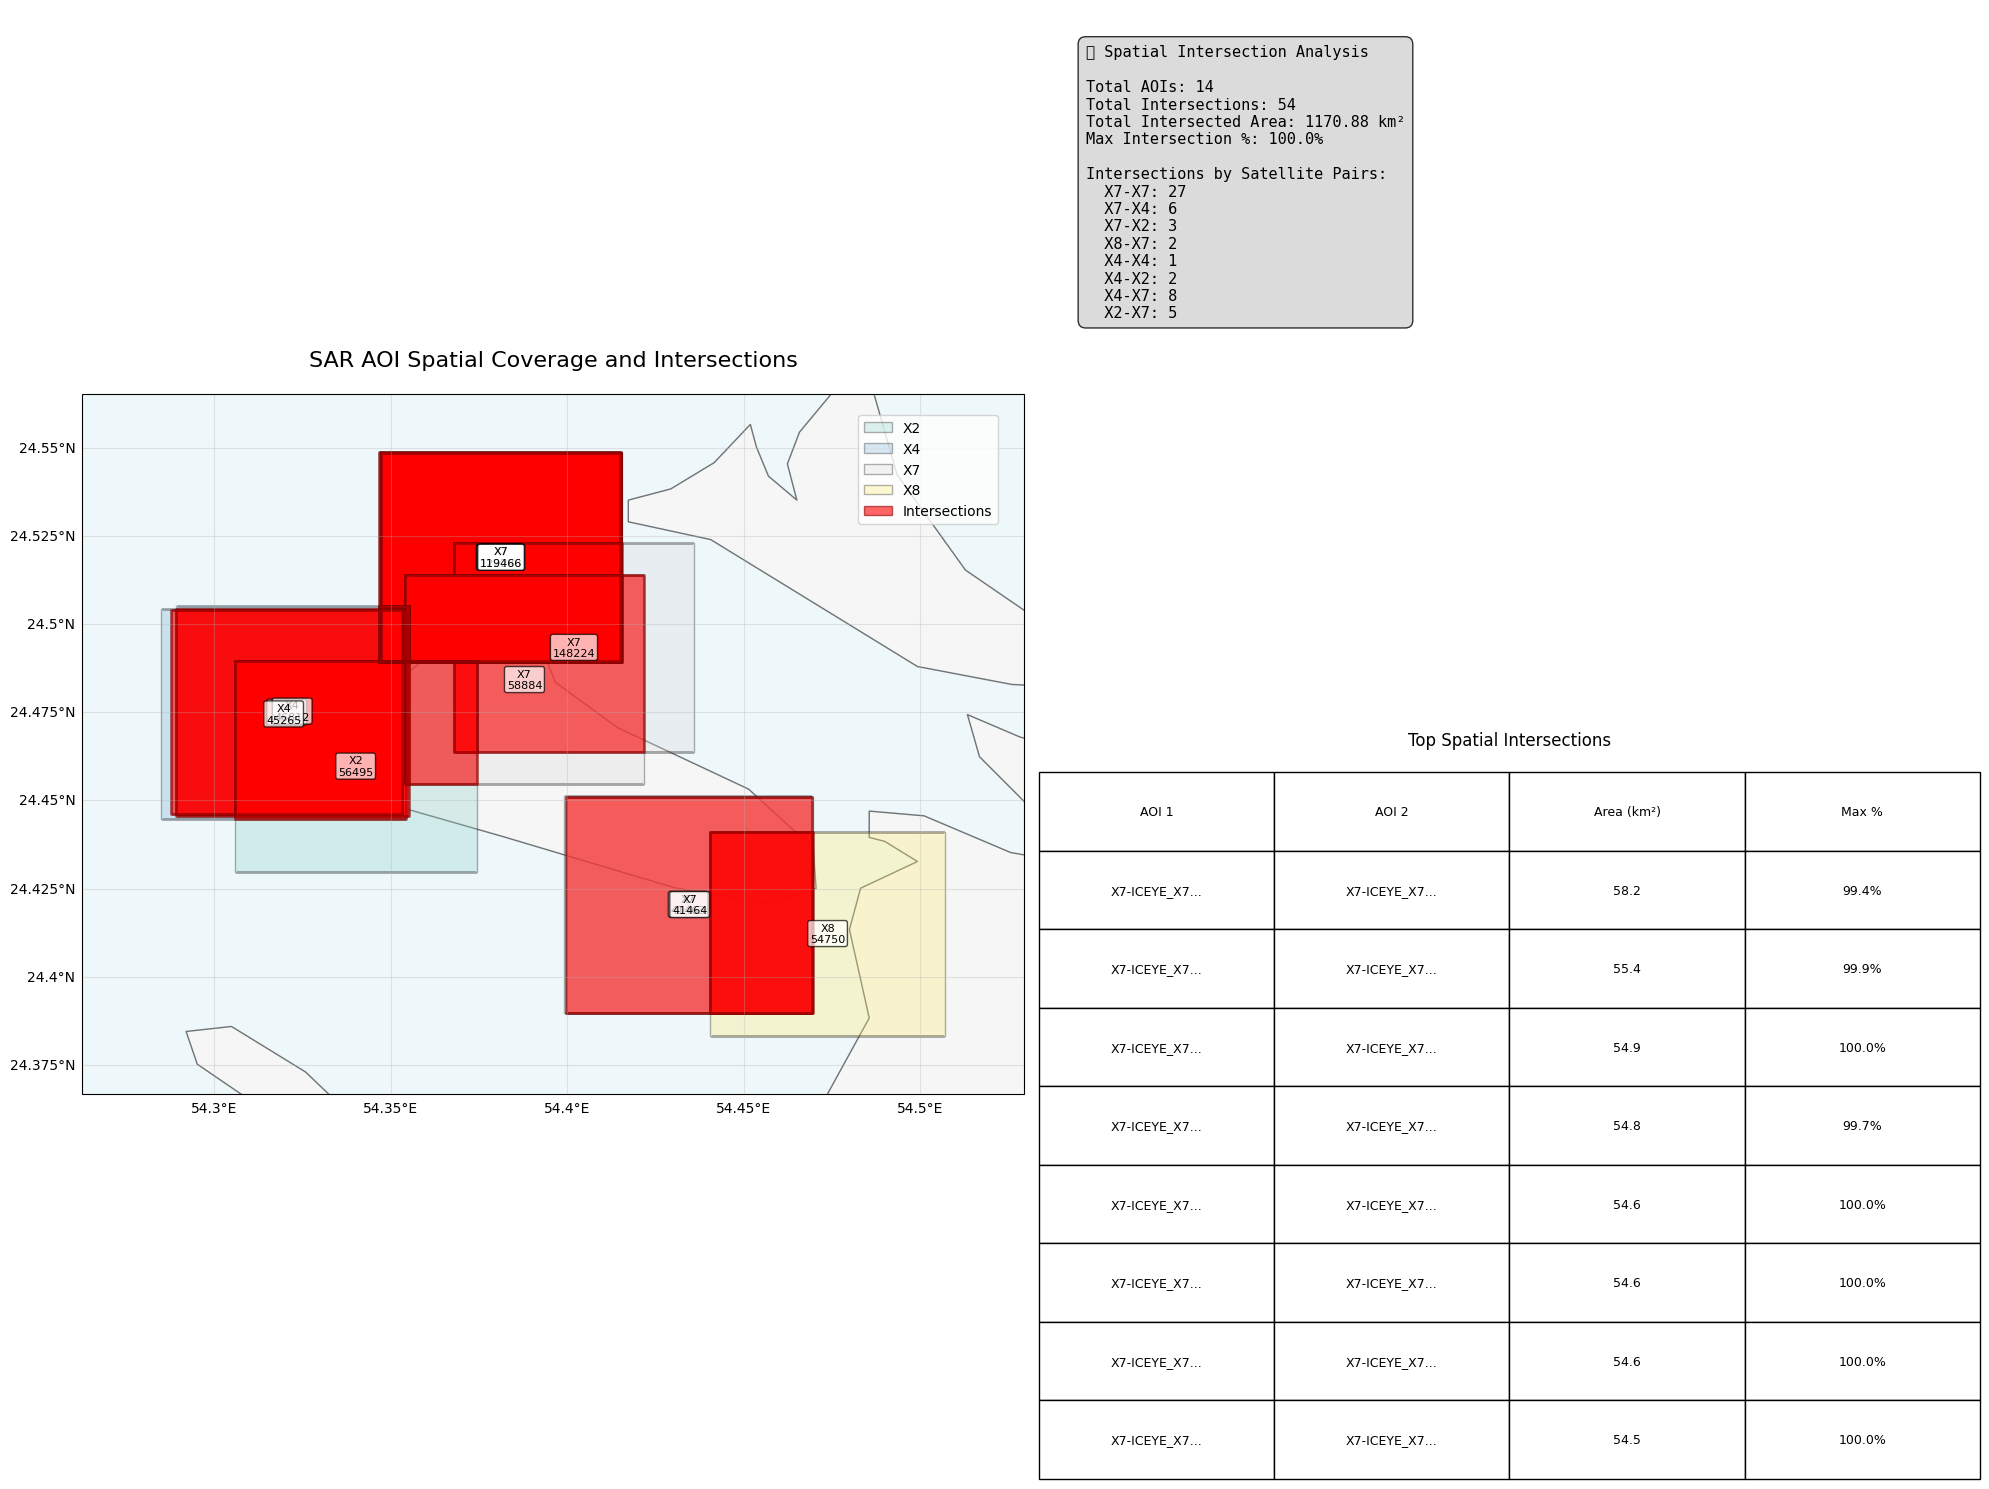

📊 Creating intersection percentage analysis...


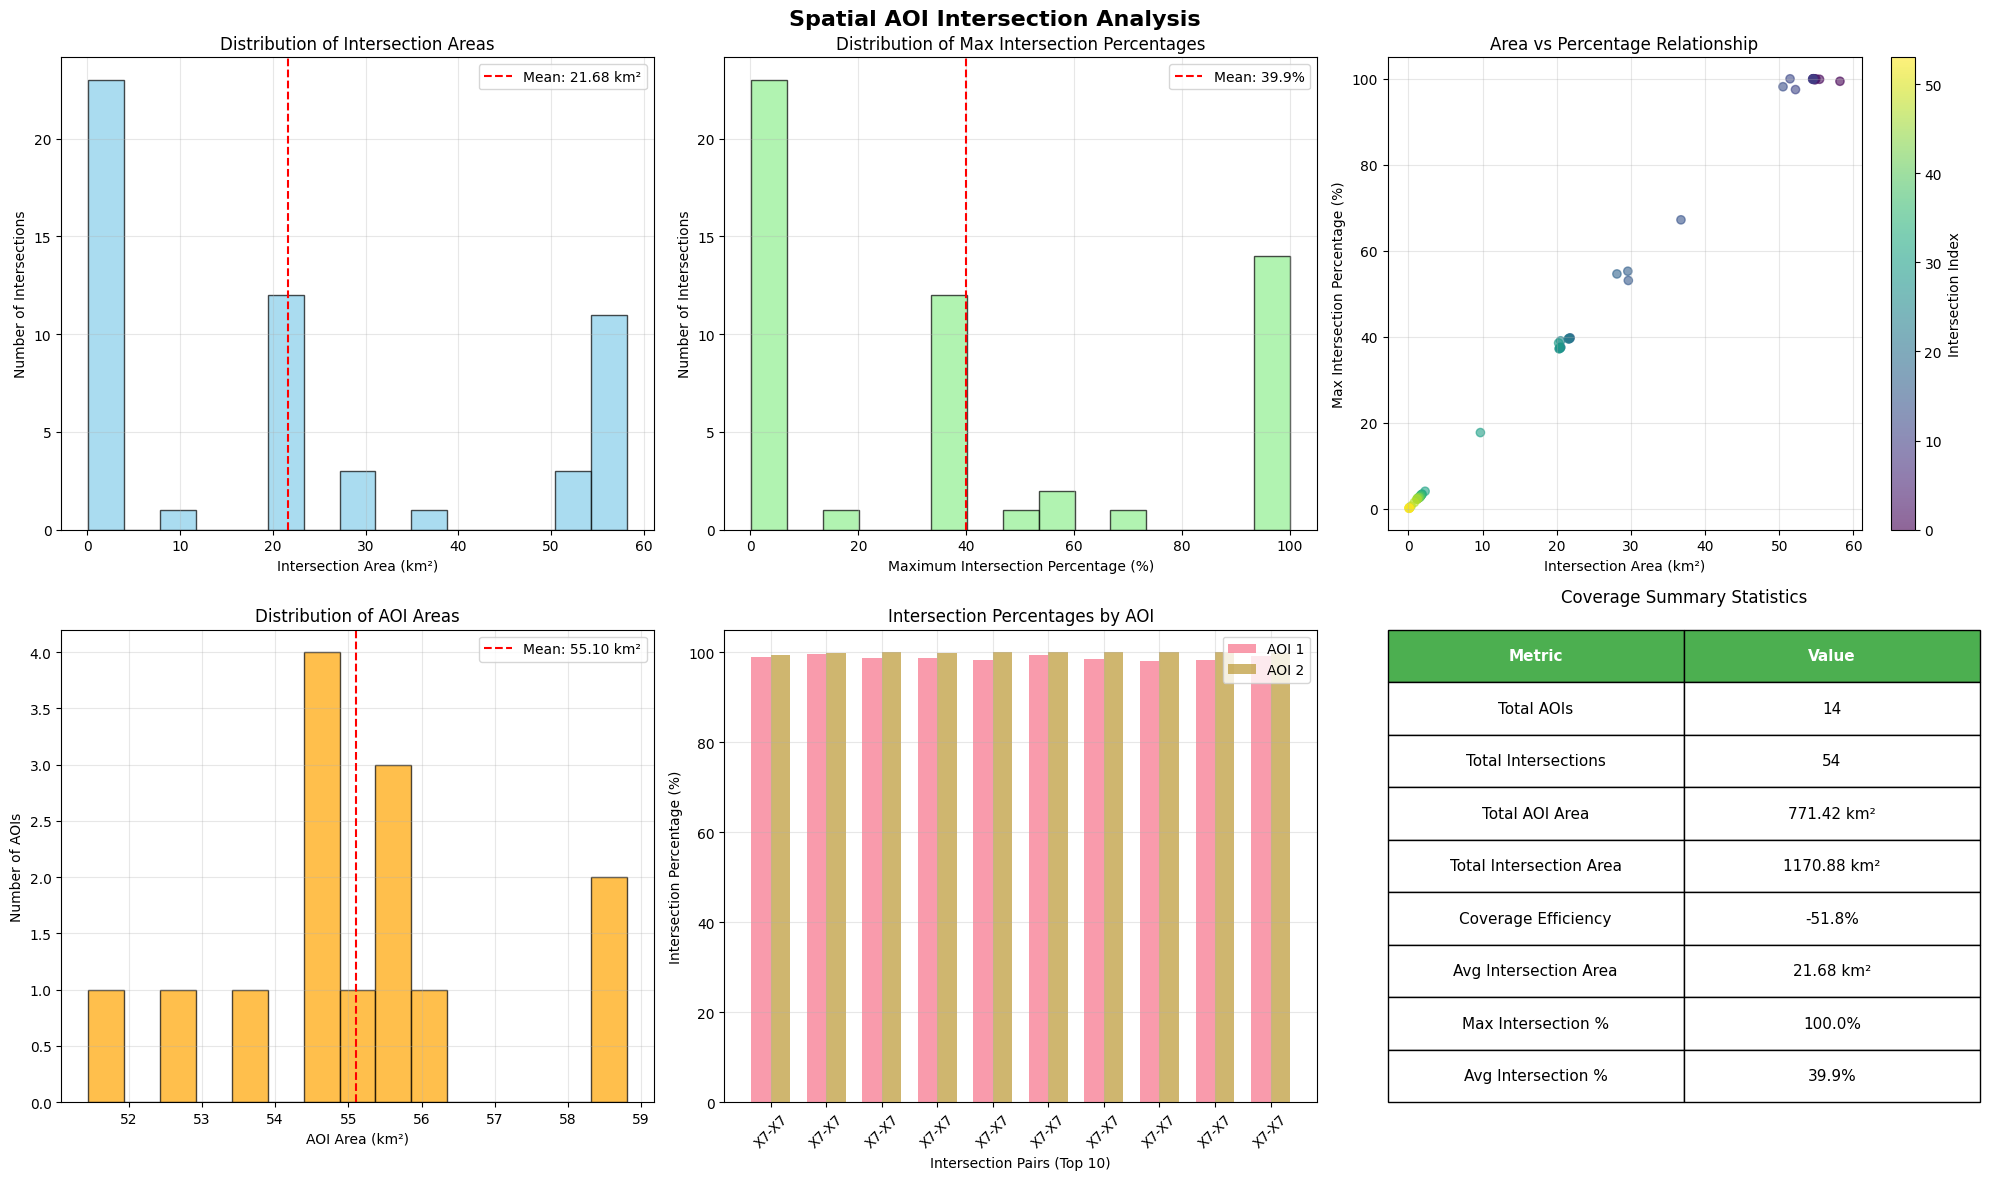

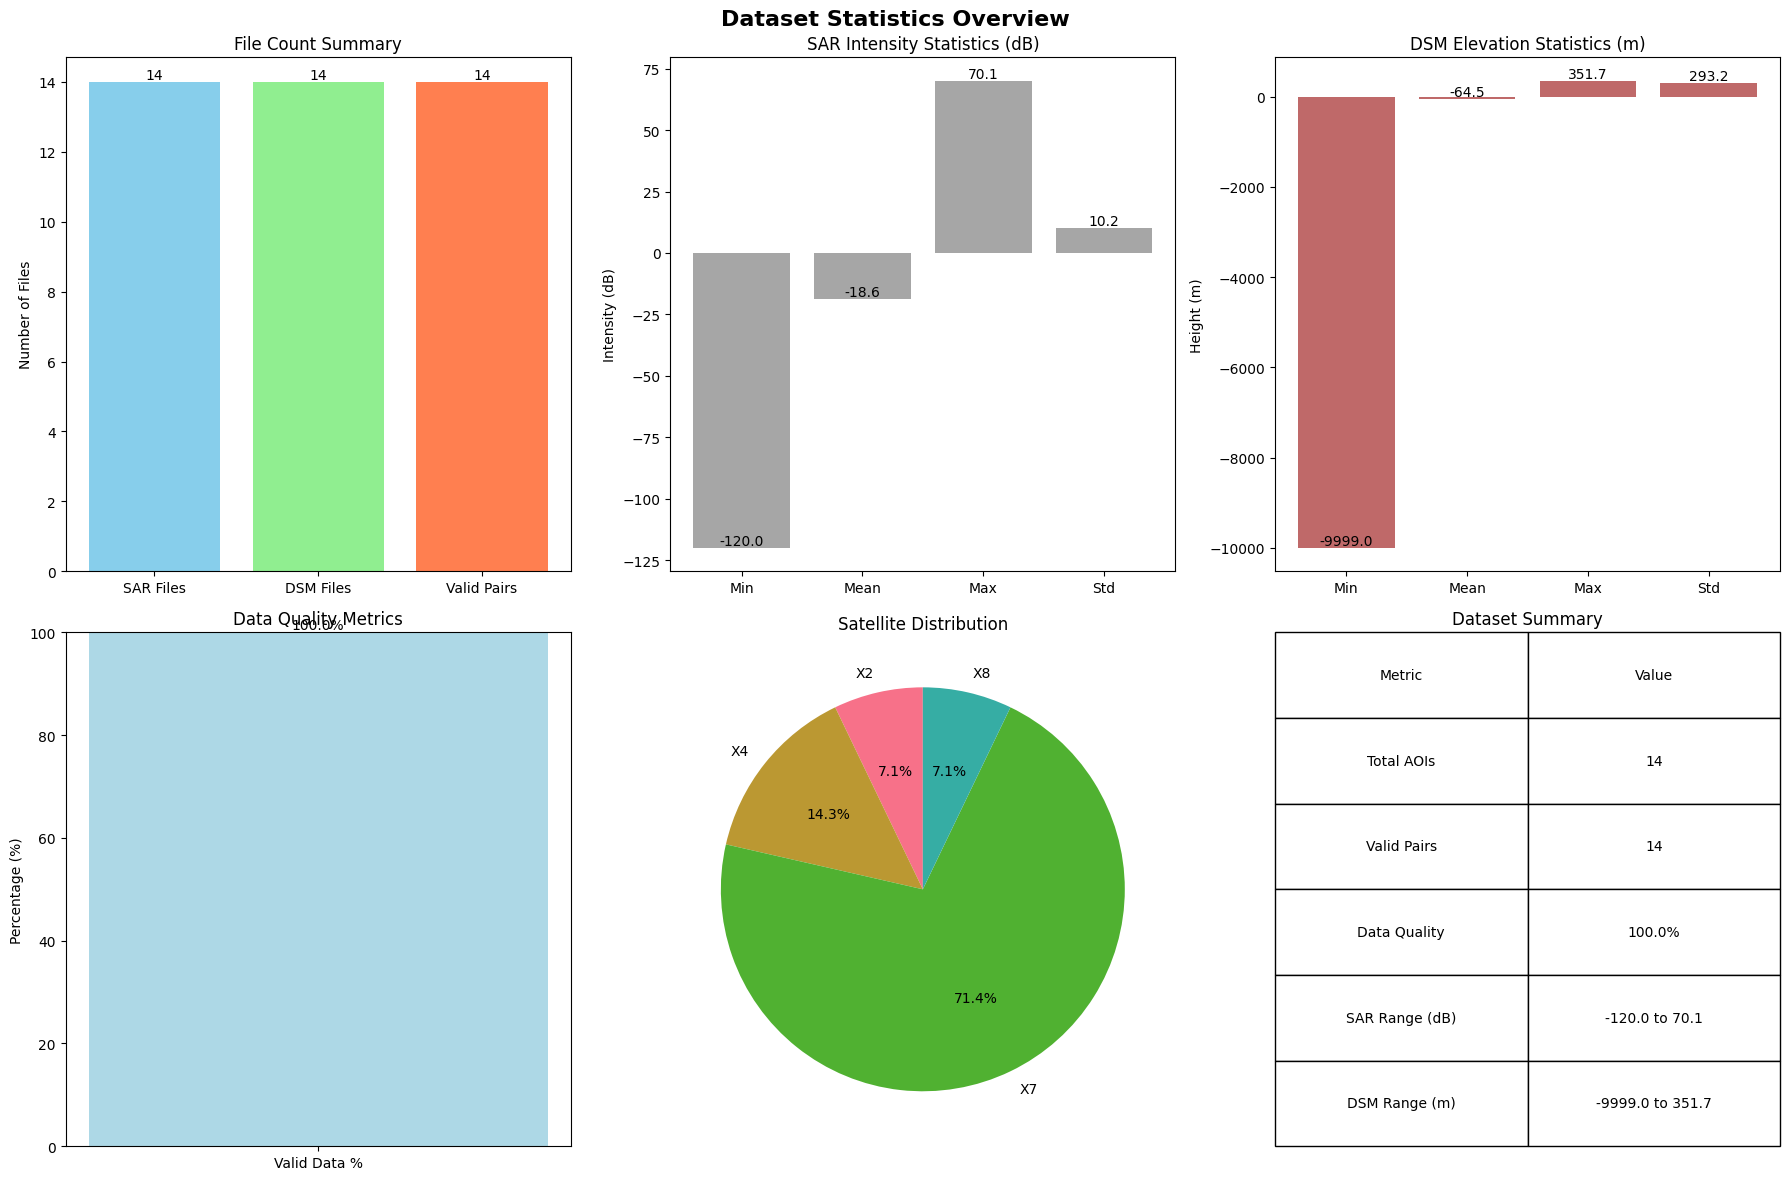

✓ Spatial intersection map saved: /app/data/sar2height/visualizations/spatial_aoi_intersections.png
✓ Intersection analysis saved: /app/data/sar2height/visualizations/intersection_analysis.png
✓ Dataset statistics saved: /app/data/sar2height/visualizations/dataset_statistics.png

✅ Spatial AOI analysis complete


In [19]:
# if can_process and n_pairs > 0:
#     print("📈 Generating dataset statistics with spatial analysis...")
    
#     try:
#         # Get enhanced statistics with spatial AOI analysis
#         data_stats = get_data_statistics(DATA_DIR)
        
#         print(f"\n📊 Dataset Statistics Summary:")
#         print(f"  • Total file pairs: {data_stats['total_pairs']}")
        
#         # Validation results
#         validation_summary = data_stats.get('validation_summary', {})
#         valid_pairs = validation_summary.get('valid_pairs', 0)
#         total_pairs = validation_summary.get('total_pairs', 0)
#         print(f"  • Valid pairs: {valid_pairs}/{total_pairs}")
        
#         # Spatial AOI analysis
#         spatial_aois = data_stats.get('spatial_aois', [])
#         intersection_analysis = data_stats.get('spatial_intersection_analysis', {})
#         intersections = intersection_analysis.get('intersections', [])
        
#         print(f"\n🗺️ Spatial AOI Analysis:")
#         print(f"  • AOIs with spatial data: {len(spatial_aois)}")
#         print(f"  • Spatial intersections found: {len(intersections)}")
        
#         if intersections:
#             summary = intersection_analysis.get('intersection_summary', {})
#             print(f"  • Total intersected area: {summary.get('total_intersected_area_km2', 0):.2f} km²")
#             print(f"  • Maximum intersection: {summary.get('max_intersection_percentage', 0):.1f}%")
            
#             # Show top 3 intersections
#             print(f"\n🎯 Top Spatial Intersections:")
#             for i, intersection in enumerate(intersections[:3]):
#                 print(f"  {i+1}. {intersection['aoi1_satellite']}-{intersection['aoi1_name']} ↔ {intersection['aoi2_satellite']}-{intersection['aoi2_name']}")
#                 print(f"     Area: {intersection['intersection_area_km2']:.2f} km² ({intersection['max_intersection_percentage']:.1f}% overlap)")
        
#         # Data value ranges
#         if 'aggregated_stats' in data_stats:
#             agg_stats = data_stats['aggregated_stats']
#             print(f"\n🎯 Data Value Ranges:")
#             if 'intensity' in agg_stats:
#                 int_agg = agg_stats['intensity']
#                 print(f"  • SAR Intensity: [{int_agg['global_min']:.1f}, {int_agg['global_max']:.1f}] dB")
#             if 'dsm' in agg_stats:
#                 dsm_agg = agg_stats['dsm']
#                 print(f"  • DSM Heights: [{dsm_agg['global_min']:.1f}, {dsm_agg['global_max']:.1f}] m")
        
#         # Create comprehensive visualizations
#         if import_success.get('visualization', False):
#             print("\n🎨 Creating spatial intersection visualizations...")
            
#             visualizer = SARDataVisualizer(figsize=(15, 10))
            
#             # 1. Spatial intersection map with projected coordinates
#             print("📍 Creating spatial AOI intersection map...")
#             fig_spatial = visualizer.plot_spatial_aoi_intersections(data_stats)
#             plt.show()
            
#             # 2. Detailed intersection percentage analysis
#             if intersections:
#                 print("📊 Creating intersection percentage analysis...")
#                 fig_analysis = visualizer.plot_intersection_percentage_analysis(data_stats)
#                 plt.show()
            
#             # 3. Traditional dataset statistics
#             dataset_stats = DatasetStats(data_stats)
#             fig_stats = visualizer.plot_data_statistics(dataset_stats)
#             plt.show()
            
#             # Save plots if VISUALIZATION_DIR is defined
#             if 'VISUALIZATION_DIR' in globals():
#                 spatial_path = Path(VISUALIZATION_DIR) / "spatial_aoi_intersections.png"
#                 analysis_path = Path(VISUALIZATION_DIR) / "intersection_analysis.png"
#                 stats_path = Path(VISUALIZATION_DIR) / "dataset_statistics.png"
                
#                 fig_spatial.savefig(spatial_path, dpi=300, bbox_inches='tight')
#                 if intersections:
#                     fig_analysis.savefig(analysis_path, dpi=300, bbox_inches='tight')
#                 fig_stats.savefig(stats_path, dpi=300, bbox_inches='tight')
                
#                 plt.close(fig_spatial)
#                 if intersections:
#                     plt.close(fig_analysis)
#                 plt.close(fig_stats)
                
#                 print(f"✓ Spatial intersection map saved: {spatial_path}")
#                 if intersections:
#                     print(f"✓ Intersection analysis saved: {analysis_path}")
#                 print(f"✓ Dataset statistics saved: {stats_path}")
        
#         print("\n✅ Spatial AOI analysis complete")
        
#     except Exception as e:
#         print(f"❌ Error in spatial analysis: {e}")
#         import traceback
#         traceback.print_exc()
#         data_stats = None
# else:
#     print("⚠️  Skipping statistics generation")
#     data_stats = None

In [22]:
data_stats

{'total_pairs': 14,
 'pair_details': [{'index': 0,
   'intensity_path': '/app/data/sar2height/run2/ICEYE_X7_SLC_SLH_123088_20210825T214159_Intensity_DB.tif',
   'dsm_path': '/app/data/sar2height/run2/ICEYE_X7_SLC_SLH_123088_20210825T214159_DSM_RADAR.tif',
   'base_name': 'ICEYE_X7_SLC_SLH_123088_20210825T214159',
   'aoi_info': {'satellite': 'X7',
    'orbit_id': '123088',
    'datetime': '20210825T214159',
    'date': '20210825',
    'time': '214159',
    'full_name': 'ICEYE_X7_SLC_SLH_123088_20210825T214159',
    'bounds': (231212.42918434733,
     2710975.1087463303,
     238065.41036481966,
     2717424.0858979705),
    'bounds_wgs84': (54.3466200902728,
     24.489250841061168,
     54.41540731316434,
     24.548608439471934),
    'polygon_wgs84': <POLYGON ((54.415 24.489, 54.415 24.549, 54.347 24.549, 54.347 24.489, 54.41...>,
    'crs': 'EPSG:32640',
    'area_km2': 55.61206948283567},
   'validation': {'files_exist': True,
    'readable': True,
    'same_dimensions': True,
    